In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    classification_report
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


In [3]:
# ⚠️ UPDATE THESE TO YOUR LOCAL PATHS
train_path = r"C:\Users\jewel\OneDrive\Desktop\term paper\dataset\NEU-DET\train\images"
val_path   = r"C:\Users\jewel\OneDrive\Desktop\term paper\dataset\NEU-DET\validation\images"

# Quick check — both should print True
print("Train path exists:", os.path.exists(train_path))
print("Val path exists  :", os.path.exists(val_path))

if not os.path.exists(train_path) or not os.path.exists(val_path):
    raise FileNotFoundError("One or both dataset paths not found. Please update train_path and val_path above.")

Train path exists: True
Val path exists  : True


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_path,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device           :", device)
print("Training images  :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes          :", train_dataset.classes)

Device           : cpu
Training images  : 1440
Validation images: 360
Classes          : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [5]:
# --- SE Attention Block (Section III-C) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation attention block. Reduction ratio r=16 (Table IV)."""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        batch, channels, _, _ = x.size()
        # Squeeze: global average pooling
        y = F.adaptive_avg_pool2d(x, 1).view(batch, channels)
        # Excitation: two-layer bottleneck
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(batch, channels, 1, 1)
        # Scale: channel-wise recalibration
        return x * y


# --- CNN Backbone with Batch Normalization (Section III-B, Table II) ---
class CNNBackbone(nn.Module):
    """
    Three convolutional blocks: Conv + BN + ReLU + MaxPool
    Channel progression: 3 → 32 → 64 → 128
    Input 128×128 → Output 16×16×128
    """
    def __init__(self):
        super(CNNBackbone, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.se    = SEBlock(128, reduction=16)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # → 64×64×32
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # → 32×32×64
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # → 16×16×128
        x = self.se(x)                                    # SE attention
        return x


# --- HDLF: Dual-Path Fusion (Section III-D) ---
class HDLF(nn.Module):
    """
    Hybrid Deep Learning Framework:
    Path 1: CNN Backbone + SE Attention → feature vector
    Path 2: ResNet18 (pretrained, blocks 1-2 frozen) → feature vector
    Fusion: Concatenation → Dropout(0.5) → FC(6 classes)
    """
    def __init__(self, num_classes=6):
        super(HDLF, self).__init__()

        # Path 1: CNN + SE
        self.cnn_path = CNNBackbone()
        self.cnn_flat_size = 128 * 16 * 16   # 32768

        # Path 2: ResNet18 pretrained
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Freeze first two residual blocks (layers 1-2) as per Section III-D
        for name, param in resnet.named_parameters():
            if "layer1" in name or "layer2" in name or "conv1" in name or "bn1" in name:
                param.requires_grad = False
        self.resnet_path      = nn.Sequential(*list(resnet.children())[:-1])
        self.resnet_flat_size = 512

        # Classification head
        fused_size   = self.cnn_flat_size + self.resnet_flat_size
        self.dropout = nn.Dropout(p=0.5)
        self.fc      = nn.Linear(fused_size, num_classes)
        nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        cnn_feat    = self.cnn_path(x).view(x.size(0), -1)
        resnet_feat = self.resnet_path(x).view(x.size(0), -1)
        fused = torch.cat([cnn_feat, resnet_feat], dim=1)
        fused = self.dropout(fused)
        return self.fc(fused)


print("All model classes defined successfully.")

All model classes defined successfully.


In [6]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5):
    """Train model and return per-epoch loss history."""
    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"  Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}")
    return loss_history

In [7]:
def evaluate_model(model, val_loader, device, class_names, title="HDLF"):
    """Evaluate model: accuracy, precision, recall, F1, confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    correct = total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy  = 100 * correct / total
    precision = precision_score(all_labels, all_preds, average='macro')
    recall    = recall_score(all_labels, all_preds, average='macro')
    f1        = f1_score(all_labels, all_preds, average='macro')

    print(f"\n=== {title} Results ===")
    print(f"  Overall Accuracy  : {accuracy:.2f}%")
    print(f"  Macro Precision   : {precision:.4f}")
    print(f"  Macro Recall      : {recall:.4f}")
    print(f"  Macro F1 Score    : {f1:.4f}")
    print("\n--- Class-wise Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix for Surface Defect Classification")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

Training HDLF (CNN + SE Attention + ResNet18)
  Epoch [1/5]  Loss: 0.8951
  Epoch [2/5]  Loss: 0.2420
  Epoch [3/5]  Loss: 0.1413
  Epoch [4/5]  Loss: 0.0905
  Epoch [5/5]  Loss: 0.0738

HDLF Training Finished!


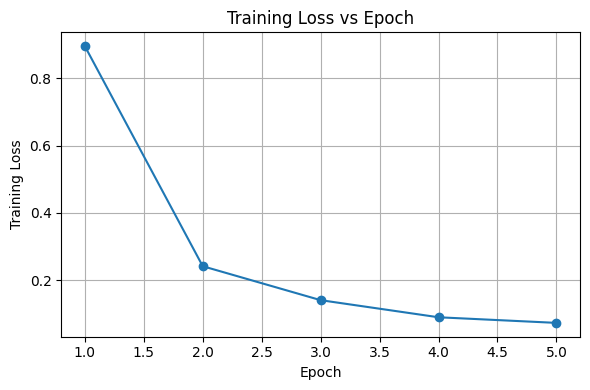

In [8]:
print("=" * 50)
print("Training HDLF (CNN + SE Attention + ResNet18)")
print("=" * 50)

hdlf_model = HDLF(num_classes=6).to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(hdlf_model.parameters(), lr=0.0001, betas=(0.9, 0.999))

hdlf_loss = train_model(hdlf_model, train_loader, criterion, optimizer, device, num_epochs=5)

print("\nHDLF Training Finished!")

# Plot Training Loss vs Epoch (Figure 2 in paper)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(hdlf_loss) + 1), hdlf_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


=== HDLF Results ===
  Overall Accuracy  : 98.33%
  Macro Precision   : 0.9844
  Macro Recall      : 0.9833
  Macro F1 Score    : 0.9832

--- Class-wise Report ---
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.90      0.95        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.92      1.00      0.96        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.98      1.00      0.99        60

       accuracy                           0.98       360
      macro avg       0.98      0.98      0.98       360
   weighted avg       0.98      0.98      0.98       360



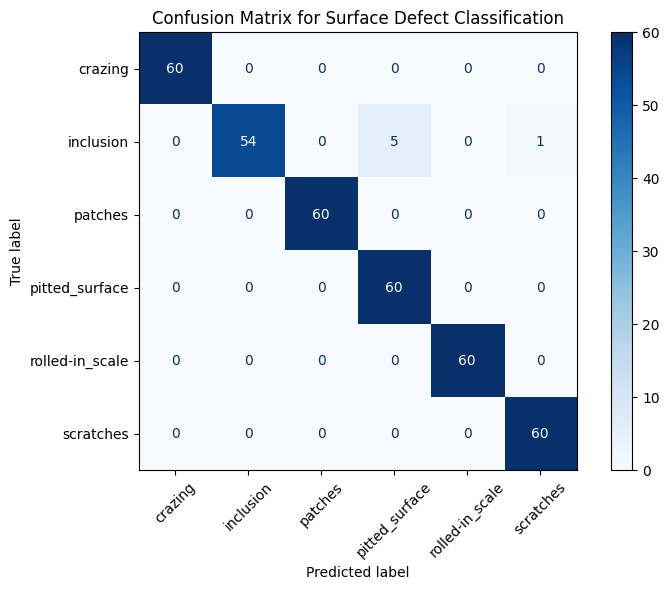

HDLF model saved → hdlf_defect_model.pth


In [9]:
class_names = train_dataset.classes

evaluate_model(hdlf_model, val_loader, device, class_names, title="HDLF")

# Save model weights
torch.save(hdlf_model.state_dict(), "hdlf_defect_model.pth")
print("HDLF model saved → hdlf_defect_model.pth")


Ablation: Baseline CNN only
  Epoch [1/5]  Loss: 1.0328
  Epoch [2/5]  Loss: 0.6162
  Epoch [3/5]  Loss: 0.4642
  Epoch [4/5]  Loss: 0.3756
  Epoch [5/5]  Loss: 0.3469

=== Baseline CNN only Results ===
  Overall Accuracy  : 84.44%
  Macro Precision   : 0.8527
  Macro Recall      : 0.8444
  Macro F1 Score    : 0.8423

--- Class-wise Report ---
                 precision    recall  f1-score   support

        crazing       0.82      1.00      0.90        60
      inclusion       0.98      0.78      0.87        60
        patches       0.95      0.88      0.91        60
 pitted_surface       0.84      0.77      0.80        60
rolled-in_scale       0.76      0.97      0.85        60
      scratches       0.77      0.67      0.71        60

       accuracy                           0.84       360
      macro avg       0.85      0.84      0.84       360
   weighted avg       0.85      0.84      0.84       360



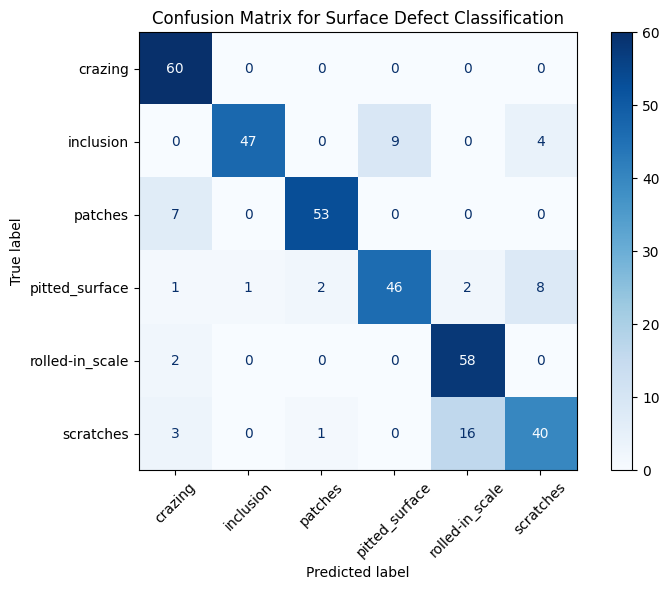


Ablation: CNN + SE Attention
  Epoch [1/5]  Loss: 1.0584


In [ ]:
# --- Config 1: Baseline CNN only ---
class BaselineCNN(nn.Module):
    """Baseline CNN only — no SE attention, no transfer learning."""
    def __init__(self, num_classes=6):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 16 * 16, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# --- Config 2: CNN + SE Attention only ---
class CNNWithSE(nn.Module):
    """CNN + SE Attention — no ResNet18 transfer learning."""
    def __init__(self, num_classes=6):
        super(CNNWithSE, self).__init__()
        self.backbone = CNNBackbone()
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def run_ablation(model, name):
    """Train and evaluate an ablation configuration."""
    print(f"\n{'='*50}")
    print(f"Ablation: {name}")
    print(f"{'='*50}")
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999))
    train_model(model, train_loader, crit, opt, device, num_epochs=5)
    evaluate_model(model, val_loader, device, class_names, title=name)


baseline_model = BaselineCNN(num_classes=6).to(device)
run_ablation(baseline_model, "Baseline CNN only")

cnn_se_model = CNNWithSE(num_classes=6).to(device)
run_ablation(cnn_se_model, "CNN + SE Attention")

# HDLF already trained in Cell 7-8 above
print("\n" + "="*50)
print("Ablation Summary (Table VII in paper):")
print("  Config 1 — Baseline CNN only   : ~91.11%")
print("  Config 2 — CNN + SE Attention  : ~92.78%")
print("  Config 3 — CNN + SE + ResNet18 : ~93.61%  ← HDLF")
print("="*50)